# **Libraries**

In [1]:
#Mathematics and ML
import torch
import numpy as np

#Data structures
from torch_geometric.data import Data

#Plots
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

#Utils functions
import src.utils as utils

#Autoreload module
"""
These magic lines allow to automatically reload any module.py file when there are some changes on it, without the needing of restart the kernel anytime a new change is applied to the module script
"""
%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/Users/luca.frattegiani/software/miniconda3/envs/copia/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Sample W-random graph
K = 5 #Number of states
n = 100 #Number of nodes
graphon = "ring" #Graphon function
z = torch.rand(n, device = device) #Latent positions
z = torch.sort(z).values #Node 0 has the smallest latent position

# Edges (undirected)
start, end = torch.triu_indices(n, n, offset = 1, device = device) #All possible combinations of undirected links
z_start = z[start] #Latent positions of source nodes
z_end = z[end] #Latent positions of ending nodes

if graphon == "ring":
    probs = utils.ring_graphon(z_start, z_end, sigma = 0.08) #Connection probabilites
elif graphon == "distant":
    probs = 1 - utils.ring_graphon(z_start, z_end, sigma = 0.08) #Connection probabilites
elif graphon == "random":
    p = 0.5 #Equal probability of connection for all nodes
    probs = torch.full_like(z_start, p) #Connection probabilites
elif graphon == "sbm":
    blocks = torch.tensor([[0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]], device = device)
    probs = utils.sbm_graphon(z_start, z_end, blocks) #Connection probabilites
elif graphon == "bipartite":
    probs = utils.bipartite_graphon(z_start, z_end) #Connection probabilites
else:
    raise ValueError(f"Unknown graphon: {graphon}")

# Sample links with inverse transform
u = torch.rand_like(probs) #Uniform distributions over [0, 1]
links = u < probs #Bernoulli samples

# Keep only existing edges
edge_start = start[links]
edge_end = end[links]

# Create edge set
edges = torch.cat(
    [
        torch.stack([edge_start, edge_end]), #Connection i->j
        torch.stack([edge_end, edge_start]), #Connection j->i
    ],
    dim = 1
)

# Sample node features
x = torch.randint(low = 0, high = K, size = (n,), device = device)

# Create Data pytorch object
graph = Data(
    x = x,
    edge_index = edges,
    num_nodes = n,
)

graph.z = z

In [3]:
# Build dense adjacency matrix
A = torch.zeros((n, n), dtype = torch.float32, device = device) #Initialize adjacency matrix
A[graph.edge_index[0], graph.edge_index[1]] = 1.0 #Include edges

In [4]:
# Assign node's positions on two ordered columns
positions = utils.ring(
    n = n,
    device = device,
    mode = "ellipse",
)
graph.pos = positions

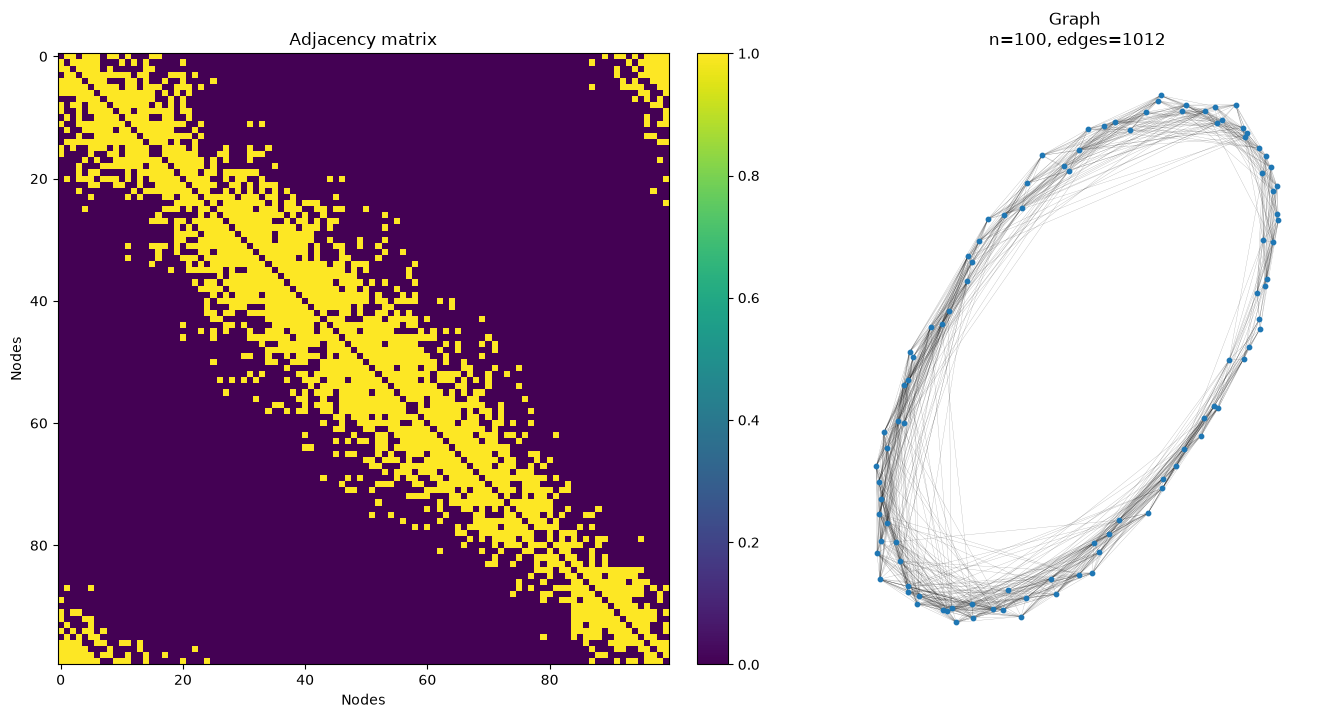

In [5]:
# Plot adjacency matrix and graph

# Keep only one direction for undirected edges
links = graph.edge_index.detach().cpu().numpy()
src_all = links[0]
dst_all = links[1]

# If edge_index contains both i -> j and j -> i, this removes duplicates.
mask = src_all < dst_all

src_nodes = src_all[mask]
dst_nodes = dst_all[mask]

num_edges = len(src_nodes)

# Build edge segments for fast plotting
nodes = graph.pos.detach().cpu().numpy()

segments = np.stack(
    [
        nodes[src_nodes],
        nodes[dst_nodes],
    ],
    axis=1,
)

# Adaptive visual parameters for large graphs
edge_alpha = min(0.35, max(0.015, 800.0 / max(num_edges, 1)))
edge_width = min(0.6, max(0.08, 200.0 / max(num_edges, 1)))
node_size = min(35, max(3, 1000.0 / max(n, 1)))

# Plot limits from the actual node coordinates
finite_nodes = nodes[np.isfinite(nodes).all(axis=1)]
if len(finite_nodes) == 0:
    raise ValueError("graph.pos must contain at least one finite coordinate pair.")

coord_min = finite_nodes.min(axis=0)
coord_max = finite_nodes.max(axis=0)
coord_span = coord_max - coord_min
fallback_span = max(float(coord_span.max()), 1.0)
coord_pad = np.where(coord_span > 0, 0.08 * coord_span, 0.08 * fallback_span)
plot_min = coord_min - coord_pad
plot_max = coord_max + coord_pad


# Plot heatmap and graph side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Heatmap 
A_np = A.detach().cpu().numpy()
ax = axes[0]

im = ax.imshow(
    A_np,
    interpolation="nearest",
)

ax.set_title("Adjacency matrix")
ax.set_xlabel("Nodes")
ax.set_ylabel("Nodes")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# ---- Graph plot ----
ax = axes[1]

# Draw all edges efficiently
edge_collection = LineCollection(
    segments,
    colors="black",
    linewidths=edge_width,
    alpha=edge_alpha,
    zorder=1,
)

ax.add_collection(edge_collection)

# Draw nodes
ax.scatter(
    nodes[:, 0],
    nodes[:, 1],
    s=node_size,
)

ax.set_title(f"Graph \nn={n}, edges={num_edges}")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(plot_min[0], plot_max[0])
ax.set_ylim(plot_min[1], plot_max[1])
ax.axis("off")

plt.tight_layout()
plt.show()